# 03. Transport Network Analysis

This notebook analyzes the three key mobility networks: Pedestrian, Cycling, and Public Transport.
To ensure clarity, each network is visualized individually.

**Data Sources:**
- **Pedestrian**: `data/processed/norrebro_pedestrian_network.gpkg`
- **Cycling**: `data/processed/norrebro_cycling.gpkg`
- **Transit**: `data/processed/norrebro_transport_stops.gpkg`

In [45]:
import sys
from pathlib import Path

project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from src.visualization import style
import contextily as ctx

style.apply_style()

## 1. Load Data

In [2]:
data_dir = project_root / "data" / "processed"

# Pedestrian (Edges and Nodes)
gdf_ped_edges = gpd.read_file(
    data_dir / "norrebro_pedestrian_network.gpkg", layer="edges"
)
# gdf_ped_nodes = gpd.read_file(data_dir / "norrebro_pedestrian_network.gpkg", layer='nodes') # Optional

# Cycling
gdf_cycle = gpd.read_file(data_dir / "norrebro_cycling.gpkg", layer="cykeldata")

# Transit
gdf_stops = gpd.read_file(data_dir / "norrebro_transport_stops.gpkg", layer="stops")
gdf_routes = gpd.read_file(data_dir / "norrebro_transport_stops.gpkg", layer="routes")

## 2. Pedestrian Network
Visualizing the density and reach of the walkable network.

In [6]:
gdf_ped_edges.head()

,u,v,key,osmid,highway,lanes,maxspeed,name,oneway,reversed,...,from,to,service,width,access,tunnel,ref,bridge,junction,geometry
0,375465,3676767770,0,654821500,tertiary,2,50,Nørre Søgade,True,False,...,375465,3676767770,,,,,,,,"LINESTRING (723836.408 6176332.406, 723839.138..."
1,375465,12248921234,0,1323685810,tertiary,3,50,Gyldenløvesgade,True,False,...,375465,12248921234,,,,,,,,"LINESTRING (723836.408 6176332.406, 723830.753..."
2,375465,298538850,0,127496087,tertiary,2,50,,True,False,...,298538850,375465,,,,,,,,"LINESTRING (723834.197 6176312.901, 723836.408..."
3,375465,12248889887,0,537418992,tertiary,3,50,Gyldenløvesgade,True,False,...,12248889887,375465,,,,,,,,"LINESTRING (723846.676 6176325.206, 723836.408..."
4,3676767770,12248921219,0,537400024,tertiary,2,50,Nørre Søgade,True,False,...,3676767770,12248921219,,,,,,,,"LINESTRING (723839.138 6176345.615, 723840.537..."


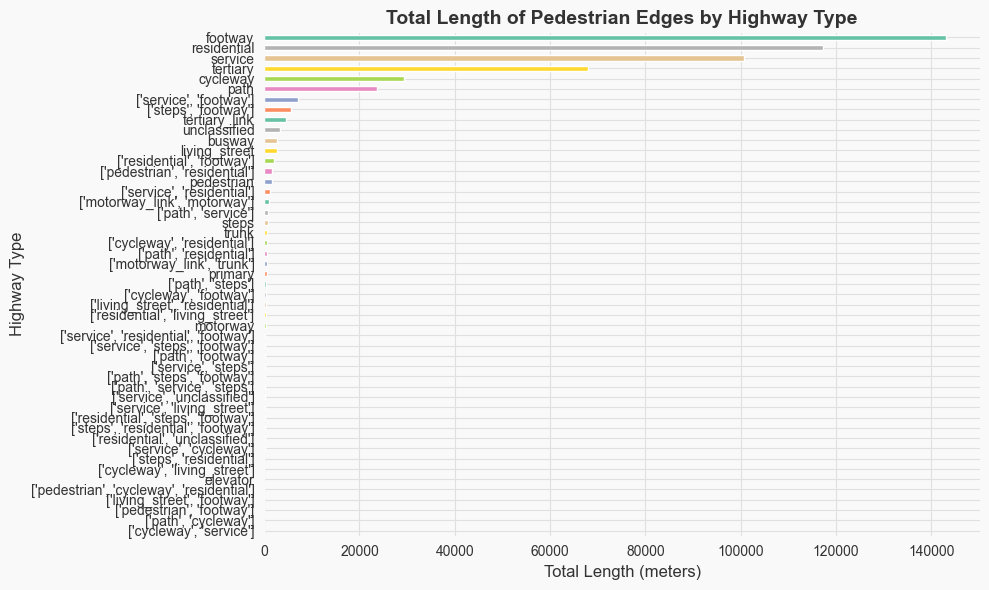

In [34]:
# plot lenght in a bargraph by highway type
fig, ax = plt.subplots(figsize=(10, 6))
gdf_ped_edges.groupby("highway")["length"].sum().sort_values().plot.barh(
    ax=ax, color=plt.get_cmap("Set2").colors
)
ax.set_title("Total Length of Pedestrian Edges by Highway Type")
ax.set_xlabel("Total Length (meters)")
ax.set_ylabel("Highway Type")
plt.tight_layout()
plt.show()

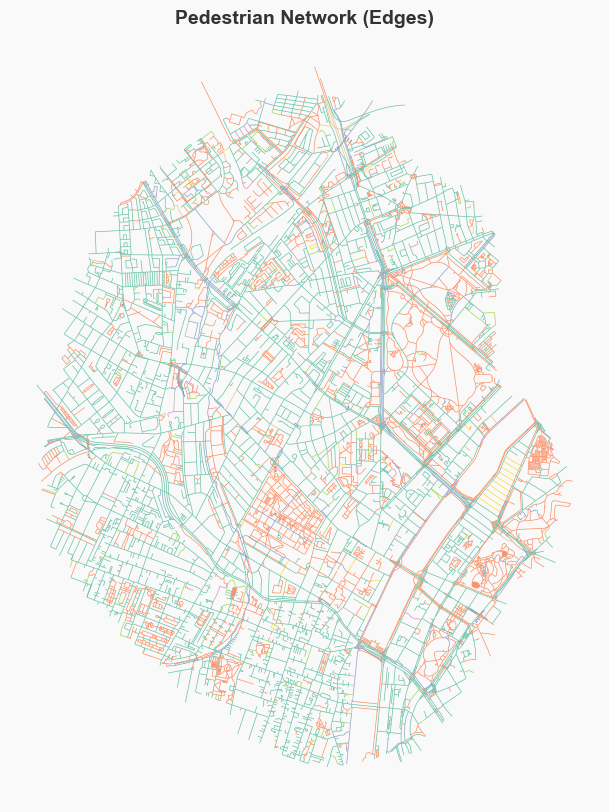

In [35]:
fig, ax = plt.subplots(figsize=(10, 10))
gdf_ped_edges.plot(ax=ax, column="highway", linewidth=0.5, cmap="Set2_r")
ax.set_title("Pedestrian Network (Edges)")
ax.set_axis_off()
plt.show()

## 3. Cycling Infrastructure
Analyzing coverage by infrastructure type (e.g., dedicated paths vs shared roads).

In [39]:
gdf_cycle.head()

,id,route_number,route_name,status,category,sub_category,municipality,standard,ogc_fid,geometry
0,5343,NaN,NaN,Existing,Cycle street,NaN,København,NaN,1,"MULTILINESTRING ((722364.52 6173594.694, 72233..."
1,668,NaN,NaN,Existing,Cycling option,NaN,København,NaN,2,"MULTILINESTRING ((725014.088 6175006.85, 72496..."
2,670,NaN,NaN,Existing,Cycling option,NaN,København,NaN,3,"MULTILINESTRING ((724925.541 6174873.44, 72486..."
3,671,NaN,NaN,Existing,Cycling option,NaN,København,NaN,4,"MULTILINESTRING ((724762.349 6174630.983, 7246..."
4,673,NaN,NaN,Existing,Cycling option,NaN,København,NaN,5,"MULTILINESTRING ((724679.159 6174506.518, 7246..."


category
Cycle path                         2361
Cycling option                      663
Green route                         307
Super cycle highway                 182
Cycle route                         117
Local cycle and walk connection       4
Cycle street                          1
Name: count, dtype: int64


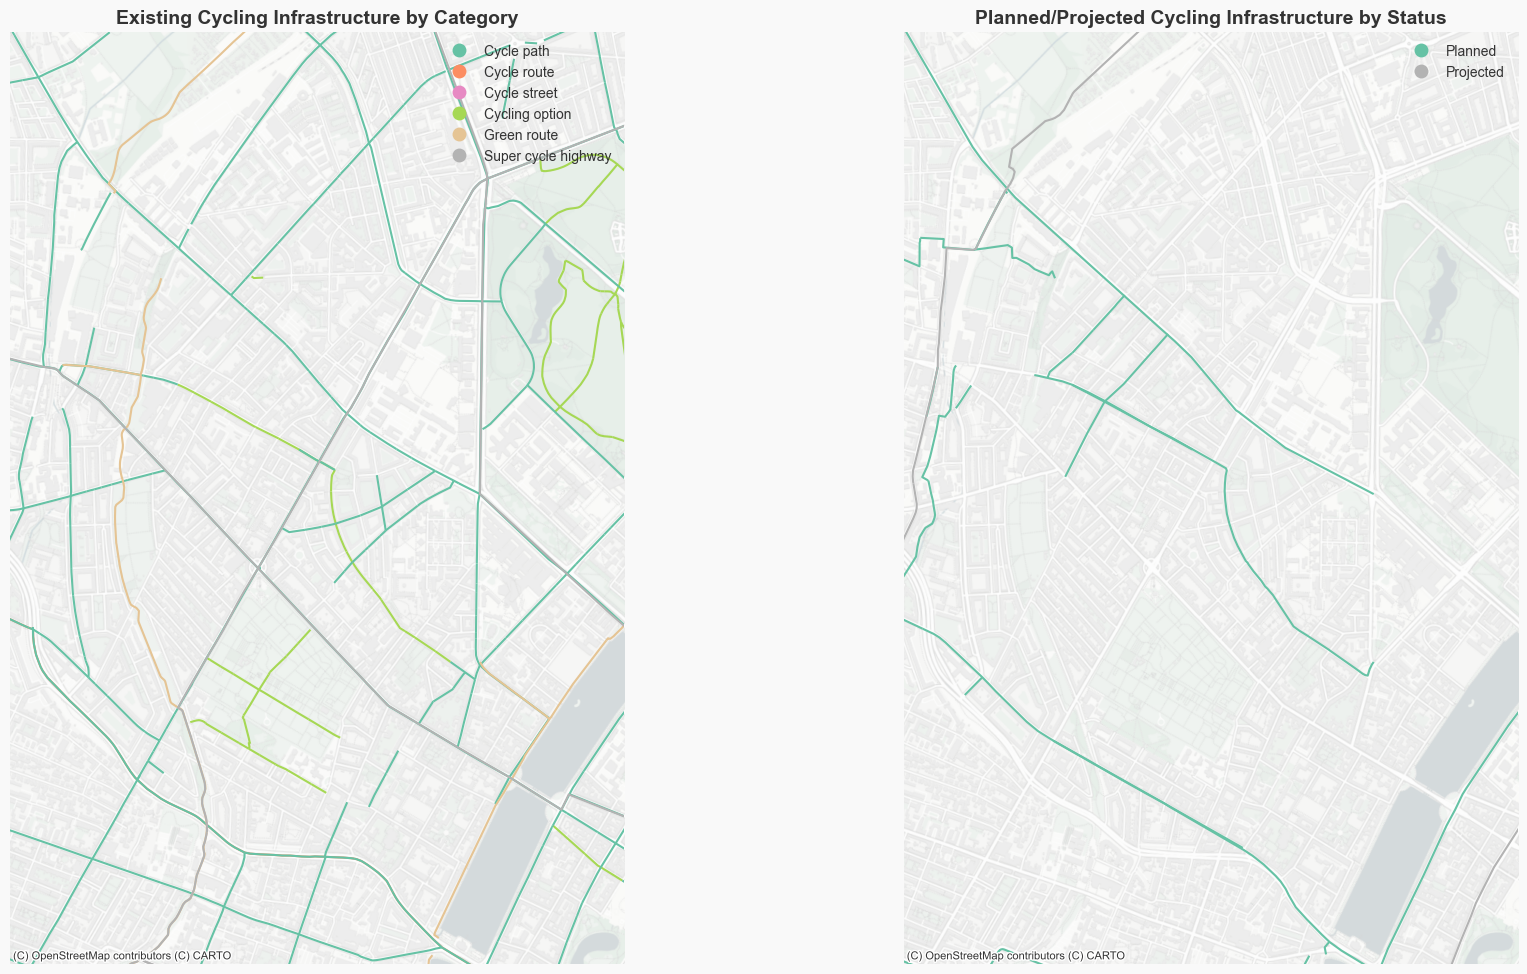

In [49]:
boundary_path = data_dir / "norrebro_boundary.gpkg"
gdf_boundary = gpd.read_file(boundary_path, layer="norrebro_boundary")
# use bbox of boundary to display cycle data
bbox = gdf_boundary.total_bounds

print(gdf_cycle["category"].value_counts())

# Split data by status
gdf_existing = gdf_cycle[gdf_cycle["status"] == "Existing"]
gdf_other = gdf_cycle[gdf_cycle["status"] != "Existing"]

# Create side-by-side maps
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Map 1: Existing infrastructure
gdf_existing.plot(column="category", ax=ax1, legend=True, cmap="Set2", linewidth=1.5)
ax1.set_xlim(bbox[0], bbox[2])
ax1.set_ylim(bbox[1], bbox[3])
ctx.add_basemap(ax1, source=ctx.providers.CartoDB.PositronNoLabels, crs="EPSG:25832")
ax1.set_title("Existing Cycling Infrastructure by Category")
ax1.set_axis_off()

# Map 2: Planned/Projected infrastructure
gdf_other.plot(column="status", ax=ax2, legend=True, cmap="Set2", linewidth=1.5)
ax2.set_xlim(bbox[0], bbox[2])
ax2.set_ylim(bbox[1], bbox[3])
ctx.add_basemap(ax2, source=ctx.providers.CartoDB.PositronNoLabels, crs="EPSG:25832")
ax2.set_title("Planned/Projected Cycling Infrastructure by Status")
ax2.set_axis_off()

plt.tight_layout()
plt.show()

## 4. Public Transport
Bus, Metro, and Train stops distribution.

In [50]:
gdf_stops.head()

,stop_id,stop_name,transport_mode,geometry
0,000008600646,Nørreport St.,train,POINT (724529.982 6176633.004)
1,000008600644,Ryparken St.,train,POINT (723574.028 6180142.009)
2,000008600645,Vesterport St.,train,POINT (723961.987 6175774.033)
3,000008600642,Nørrebro St.,train,POINT (722295.006 6178457.97)
4,000008600640,Fuglebakken St.,train,POINT (721671.01 6177822.02)


In [54]:
gdf_routes.head()

,route_id,route_short_name,transport_mode,direction_id,geometry
0,10359_3,35,bus,0,"LINESTRING (727364.852 6172636.585, 727364.852..."
1,10359_3,35,bus,1,"LINESTRING (729830.659 6170930.378, 729830.659..."
2,11748_2,RE,train,0,"LINESTRING (675978.031 6124026.013, 675978.031..."
3,16424_3,834,bus,0,"LINESTRING (710883.045 6181146.887, 710883.045..."
4,16424_3,834,bus,1,"LINESTRING (713681.364 6180457.146, 713681.364..."


transport_mode
bus      2581
train      62
metro      44
Name: count, dtype: int64


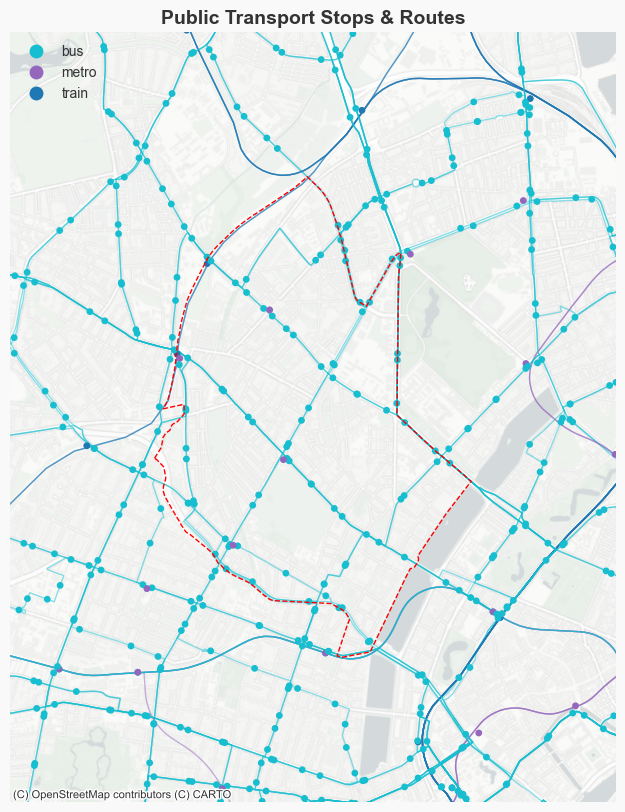

In [68]:
if "transport_mode" in gdf_stops.columns:
    # Count stops by mode
    print(gdf_stops["transport_mode"].value_counts())

    fig, ax = plt.subplots(figsize=(10, 10))

    # Plot routes faintly
    gdf_routes.plot(
        ax=ax, column="transport_mode", cmap="tab10_r", linewidth=1, alpha=0.5, zorder=1
    )
    gdf_stops.plot(
        column="transport_mode",
        ax=ax,
        legend=True,
        cmap="tab10_r",
        markersize=15,
        zorder=2,
    )

    gdf_boundary.plot(
        ax=ax, facecolor="none", edgecolor="red", linewidth=1, linestyle="--", zorder=3
    )

    ax.set_xlim(bbox[0] - 1000, bbox[2] + 1000)  # Add small buffer to bbox
    ax.set_ylim(bbox[1] - 1000, bbox[3] + 1000)  # Add small buffer to bbox
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels, crs="EPSG:25832")

    ax.set_title("Public Transport Stops & Routes")
    ax.set_axis_off()
    plt.show()